# Clean Energy Dominance Prediction using Logistic Regression

### Problem Statement
The increasing need for sustainable energy requires understanding whether a country’s electricity generation is dominated by clean energy sources. This project aims to predict whether clean energy is dominant or not using Logistic Regression by analyzing country, region, year, and energy composition indicators. The model helps classify countries based on their energy profile and supports data-driven insights into clean energy adoption.

# Steps to be followed
1. Importing Required Libraries
2. Load Dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Missing values)
6. Data Visualization
7. Label Encoding
8. Feature Selection (x,y)
9. Feature Scaling
10. Train-Test Split
11. Logistic Regression Model Training and Prediction
12. Model Evaluation (Accuracy Score,Classification Report)
13. GridSearchCV
14. ROC Curve Analysis
15. Threshold Tuning
16. Improving Model Performance with Advanced Algorithms

# Importing Required Libraries

In [66]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score,classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler,MinMaxScaler

In [68]:
import warnings
warnings.filterwarnings("ignore")

# Loading the Dataset

In [69]:
df=pd.read_csv(r"C:\Users\HP\Downloads\Global renewable and fossil fuel energy.csv")
df

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
0,Aruba,ABW,Latin America & Caribbean,2000,0.2,NaN,0.000000,100.000000,100.000000,False
1,Aruba,ABW,Latin America & Caribbean,2001,0.2,NaN,0.000000,100.000000,100.000000,False
2,Aruba,ABW,Latin America & Caribbean,2002,0.2,NaN,0.000000,100.000000,100.000000,False
3,Aruba,ABW,Latin America & Caribbean,2003,0.2,NaN,0.000000,100.000000,100.000000,False
4,Aruba,ABW,Latin America & Caribbean,2004,0.2,NaN,0.000000,100.000000,100.000000,False
...,...,...,...,...,...,...,...,...,...,...
4852,Zimbabwe,ZWE,Sub-Saharan Africa,2018,79.7,0.0,63.033301,44.113566,107.146867,True
4853,Zimbabwe,ZWE,Sub-Saharan Africa,2019,81.0,0.0,68.845218,48.223229,117.068447,True
4854,Zimbabwe,ZWE,Sub-Saharan Africa,2020,84.1,0.0,60.785554,41.120935,101.906489,True
4855,Zimbabwe,ZWE,Sub-Saharan Africa,2021,82.4,0.0,72.628388,29.404206,102.032594,True


# Data Preprocessing

In [70]:
df.shape

(4857, 10)

In [71]:
df.head()

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
0,Aruba,ABW,Latin America & Caribbean,2000,0.2,NaN,0.0,100.0,100.0,False
1,Aruba,ABW,Latin America & Caribbean,2001,0.2,NaN,0.0,100.0,100.0,False
2,Aruba,ABW,Latin America & Caribbean,2002,0.2,NaN,0.0,100.0,100.0,False
3,Aruba,ABW,Latin America & Caribbean,2003,0.2,NaN,0.0,100.0,100.0,False
4,Aruba,ABW,Latin America & Caribbean,2004,0.2,NaN,0.0,100.0,100.0,False


In [72]:
df.tail()

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
4852,Zimbabwe,ZWE,Sub-Saharan Africa,2018,79.7,0.0,63.033301,44.113566,107.146867,True
4853,Zimbabwe,ZWE,Sub-Saharan Africa,2019,81.0,0.0,68.845218,48.223229,117.068447,True
4854,Zimbabwe,ZWE,Sub-Saharan Africa,2020,84.1,0.0,60.785554,41.120935,101.906489,True
4855,Zimbabwe,ZWE,Sub-Saharan Africa,2021,82.4,0.0,72.628388,29.404206,102.032594,True
4856,Zimbabwe,ZWE,Sub-Saharan Africa,2022,NaN,0.0,NaN,31.001608,NaN,False


In [73]:
df.sample()

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
884,"Congo, Dem. Rep.",COD,Sub-Saharan Africa,2011,96.2,3.692566,90.823968,1.111251,91.935219,True


In [74]:
df.columns

Index(['country', 'country_code', 'region', 'year', 'renewable_energy_percent',
       'fossil_fuel_energy_percent', 'electricity_from_renewables_percent',
       'electricity_from_fossil_percent', 'total_electricity_share',
       'clean_energy_dominant'],
      dtype='object')

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4857 entries, 0 to 4856
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              4857 non-null   object 
 1   country_code                         4857 non-null   object 
 2   region                               4857 non-null   object 
 3   year                                 4857 non-null   int64  
 4   renewable_energy_percent             4702 non-null   float64
 5   fossil_fuel_energy_percent           3380 non-null   float64
 6   electricity_from_renewables_percent  4396 non-null   float64
 7   electricity_from_fossil_percent      4648 non-null   float64
 8   total_electricity_share              4359 non-null   float64
 9   clean_energy_dominant                4857 non-null   bool   
dtypes: bool(1), float64(5), int64(1), object(3)
memory usage: 346.4+ KB


In [76]:
df.describe()

,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share
count,4857.000000,4702.000000,3380.000000,4396.000000,4648.000000,4359.000000
mean,2011.030471,29.850936,41.378435,29.723594,64.039153,96.028676
std,6.624015,29.534705,38.943092,31.622569,34.195710,12.709192
min,2000.000000,0.000000,-61.378855,0.000000,0.000000,19.417640
25%,2005.000000,4.400000,0.000000,2.180238,37.070009,99.279028
50%,2011.000000,19.100000,39.038562,16.831798,73.163972,100.000000
75%,2017.000000,50.175000,81.117627,53.471942,96.965113,100.001417
max,2022.000000,98.300000,99.994305,100.000000,100.000000,172.448980


# Checking Null Values

Before training the model, it is important to identify and handle missing values in the dataset.

In [77]:
df.isnull().sum()

country                                   0
country_code                              0
region                                    0
year                                      0
renewable_energy_percent                155
fossil_fuel_energy_percent             1477
electricity_from_renewables_percent     461
electricity_from_fossil_percent         209
total_electricity_share                 498
clean_energy_dominant                     0
dtype: int64

In [78]:
df.isnull().sum() * 100/len(df)

country                                 0.000000
country_code                            0.000000
region                                  0.000000
year                                    0.000000
renewable_energy_percent                3.191270
fossil_fuel_energy_percent             30.409718
electricity_from_renewables_percent     9.491456
electricity_from_fossil_percent         4.303068
total_electricity_share                10.253243
clean_energy_dominant                   0.000000
dtype: float64

<Axes: >

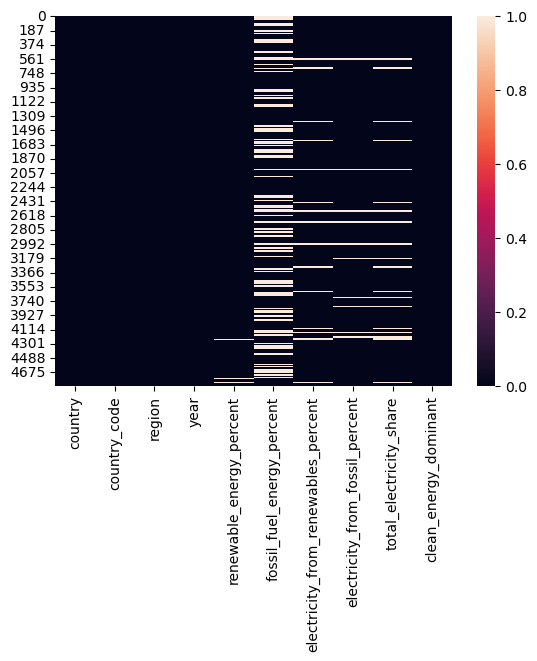

In [79]:
sns.heatmap(df.isnull())

# Data Wrangling (Filling Null/Missing Values)

In [80]:
df

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
0,Aruba,ABW,Latin America & Caribbean,2000,0.2,NaN,0.000000,100.000000,100.000000,False
1,Aruba,ABW,Latin America & Caribbean,2001,0.2,NaN,0.000000,100.000000,100.000000,False
2,Aruba,ABW,Latin America & Caribbean,2002,0.2,NaN,0.000000,100.000000,100.000000,False
3,Aruba,ABW,Latin America & Caribbean,2003,0.2,NaN,0.000000,100.000000,100.000000,False
4,Aruba,ABW,Latin America & Caribbean,2004,0.2,NaN,0.000000,100.000000,100.000000,False
...,...,...,...,...,...,...,...,...,...,...
4852,Zimbabwe,ZWE,Sub-Saharan Africa,2018,79.7,0.0,63.033301,44.113566,107.146867,True
4853,Zimbabwe,ZWE,Sub-Saharan Africa,2019,81.0,0.0,68.845218,48.223229,117.068447,True
4854,Zimbabwe,ZWE,Sub-Saharan Africa,2020,84.1,0.0,60.785554,41.120935,101.906489,True
4855,Zimbabwe,ZWE,Sub-Saharan Africa,2021,82.4,0.0,72.628388,29.404206,102.032594,True


In [81]:
num_cols = ['renewable_energy_percent','fossil_fuel_energy_percent','electricity_from_renewables_percent',
            'electricity_from_fossil_percent','total_electricity_share']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

<Axes: >

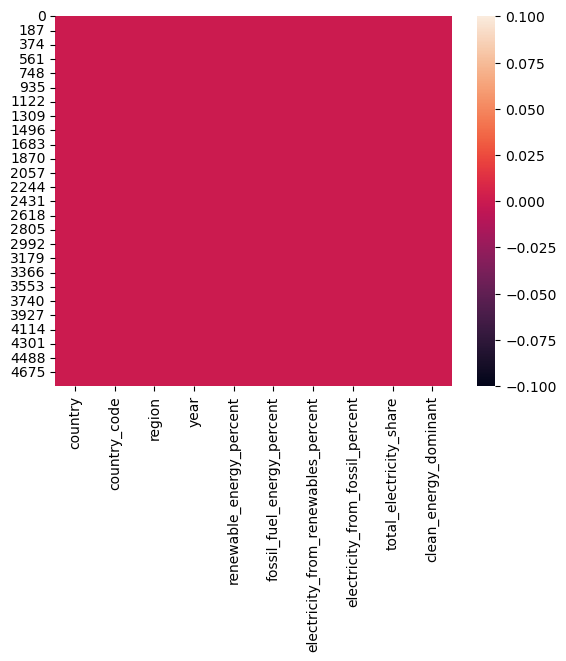

In [82]:
sns.heatmap(df.isnull())

In [83]:
df.isnull().sum()

country                                0
country_code                           0
region                                 0
year                                   0
renewable_energy_percent               0
fossil_fuel_energy_percent             0
electricity_from_renewables_percent    0
electricity_from_fossil_percent        0
total_electricity_share                0
clean_energy_dominant                  0
dtype: int64

# Data Visualization 

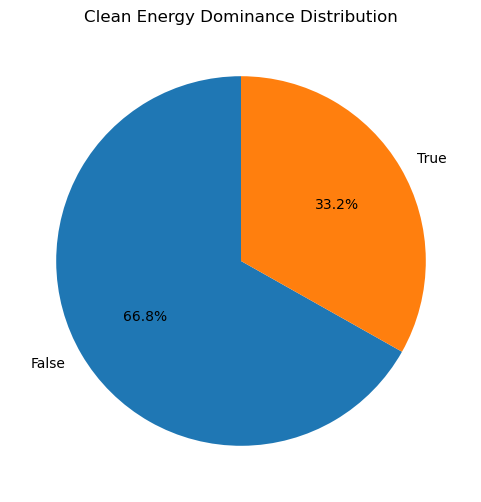

In [84]:
df['clean_energy_dominant'].value_counts().plot(
    kind='pie',autopct='%1.1f%%',figsize=(6,6),startangle=90)
plt.title("Clean Energy Dominance Distribution")
plt.ylabel("")
plt.show()


Most countries are not dominated by clean energy, showing fossil fuels still dominate globally.

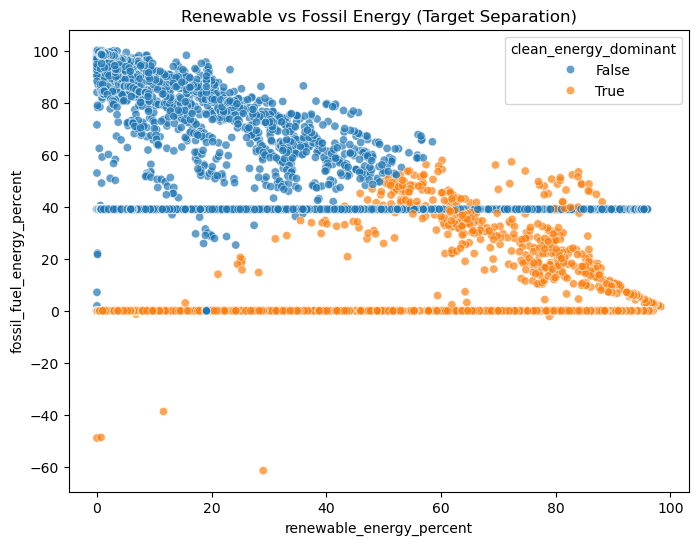

In [85]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='renewable_energy_percent',
    y='fossil_fuel_energy_percent',
    hue='clean_energy_dominant',
    data=df,
    alpha=0.7
)
plt.title("Renewable vs Fossil Energy (Target Separation)")
plt.show()

Higher renewable energy adoption is associated with lower fossil fuel dependency.

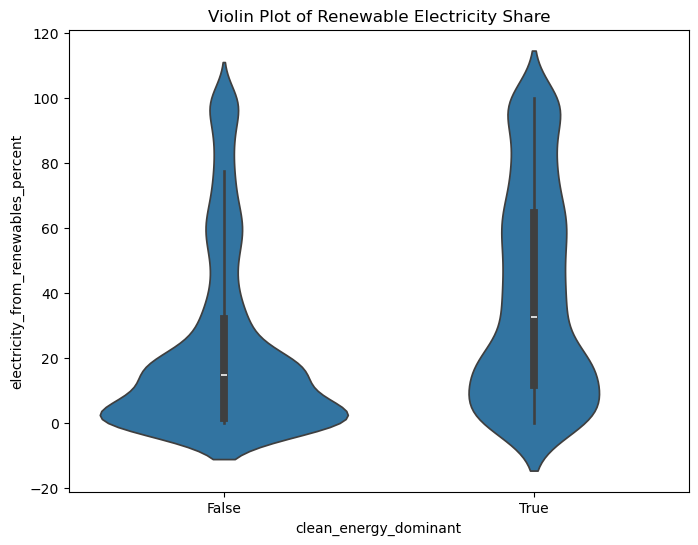

In [86]:
plt.figure(figsize=(8,6))
sns.violinplot(
    x='clean_energy_dominant',
    y='electricity_from_renewables_percent',
    data=df
)
plt.title("Violin Plot of Renewable Electricity Share")
plt.show()

Clean-energy-dominant countries generate a significantly higher share of electricity from renewable sources.

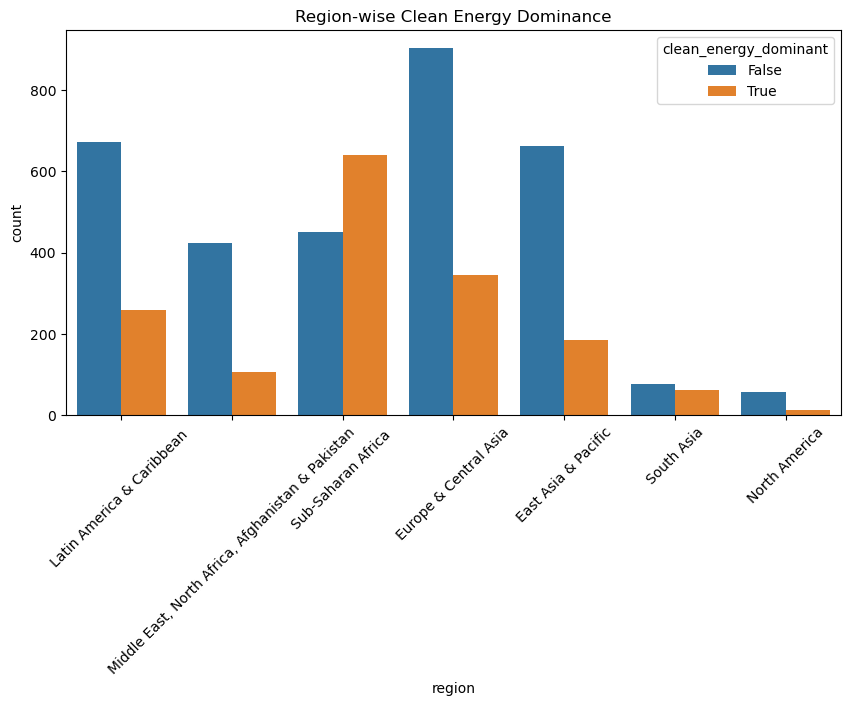

In [87]:
plt.figure(figsize=(10,5))
sns.countplot(x='region',hue='clean_energy_dominant',data=df)
plt.xticks(rotation=45)
plt.title("Region-wise Clean Energy Dominance")
plt.show()


Clean energy dominance varies significantly across regions due to differences in energy policies and resources.

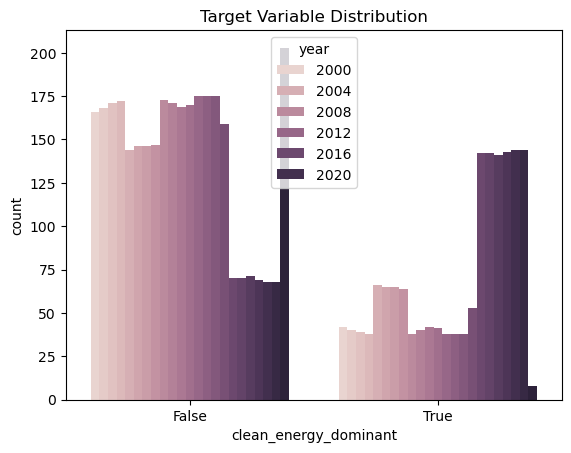

In [88]:
sns.countplot(x='clean_energy_dominant', data=df,hue='year')
plt.title("Target Variable Distribution")
plt.show()

Clean energy dominance has gradually increased over time but remains less common than fossil dominance.

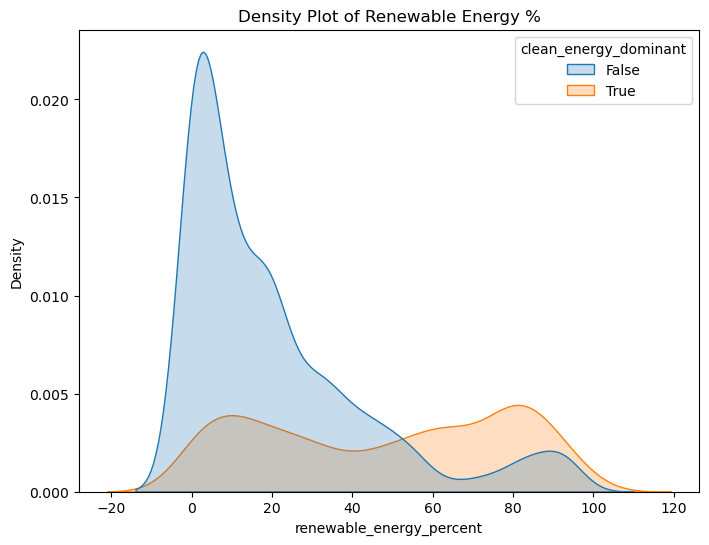

In [89]:
plt.figure(figsize=(8,6))
sns.kdeplot(
    data=df,
    x='renewable_energy_percent',
    hue='clean_energy_dominant',
    fill=True
)
plt.title("Density Plot of Renewable Energy %")
plt.show()

Higher renewable energy percentages strongly indicate clean energy dominance.

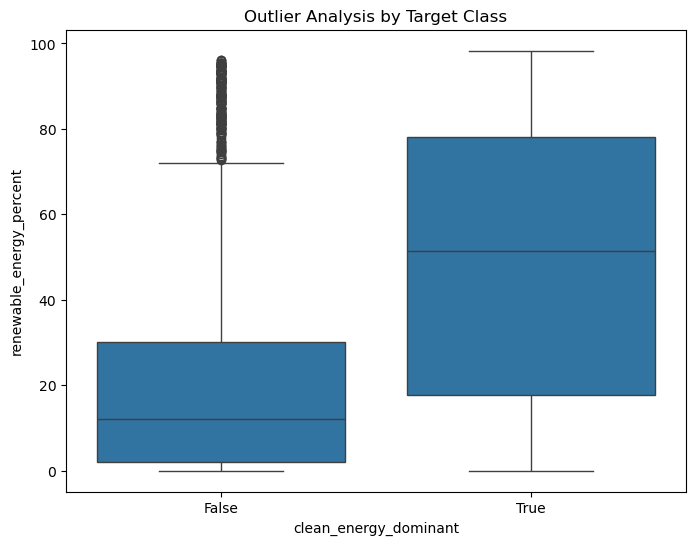

In [90]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='clean_energy_dominant',
    y='renewable_energy_percent',
    data=df
)
plt.title("Outlier Analysis by Target Class")
plt.show()

Clean-energy-dominant countries consistently maintain higher renewable energy levels.

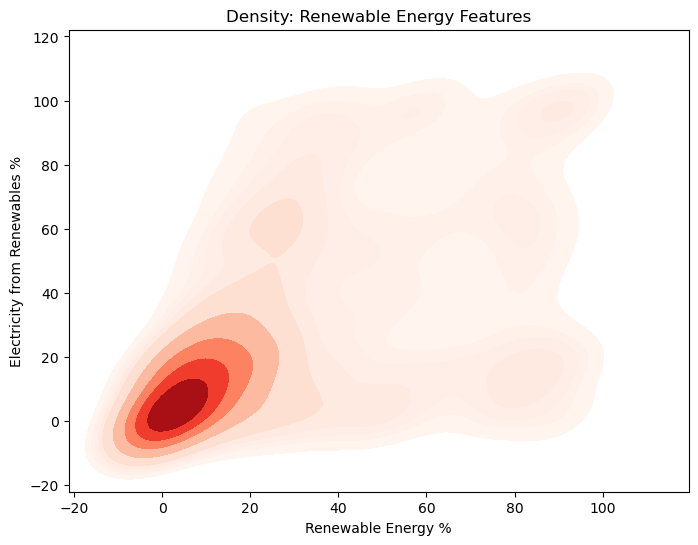

In [91]:
plt.figure(figsize=(8,6))
sns.kdeplot(
    x=df['renewable_energy_percent'],
    y=df['electricity_from_renewables_percent'],
    cmap='Reds',
    fill=True,
    thresh=0.05,
    levels=10)

plt.xlabel("Renewable Energy %")
plt.ylabel("Electricity from Renewables %")
plt.title("Density: Renewable Energy Features")
plt.show()

Higher renewable energy production is strongly linked with clean energy dominance.

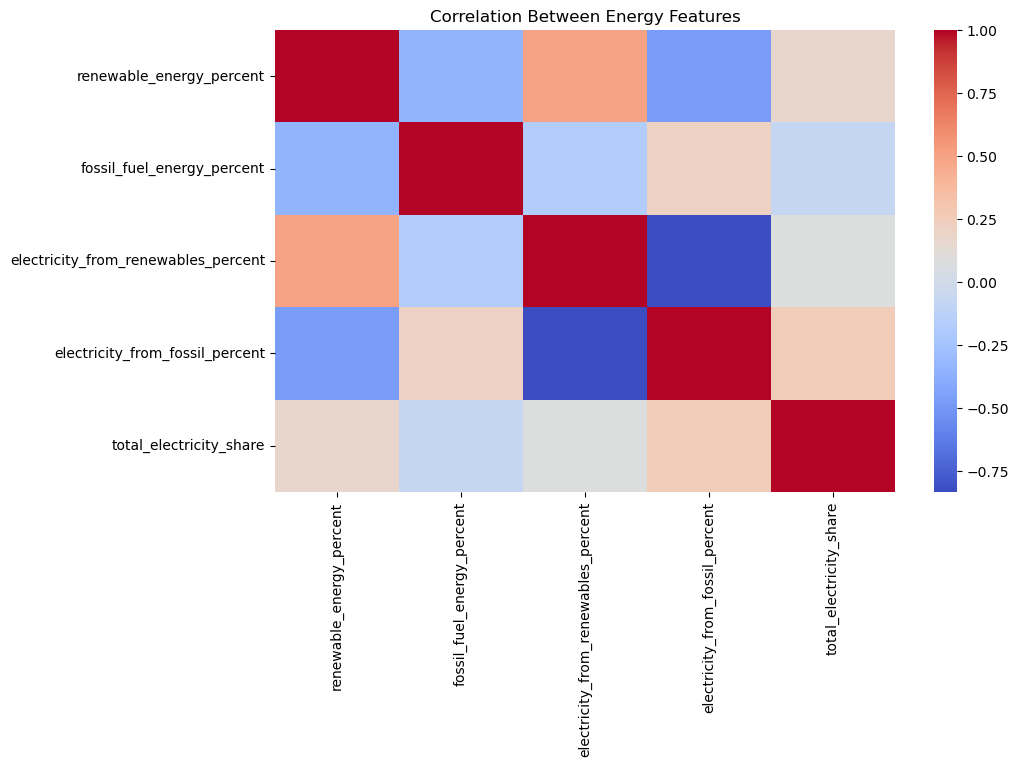

In [92]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(),cmap='coolwarm',annot=False)
plt.title("Correlation Between Energy Features")
plt.show()

Renewable energy features are positively correlated with each other and negatively correlated with fossil energy indicators.

# Label Encoding

Categorical features are converted into numerical values using Label Encoding.

In [93]:
cat_cols = df.select_dtypes(include='object')

In [94]:
label = LabelEncoder()
for c in cat_cols:
    df[c] = label.fit_transform(df[c])

# Feature Selection (x, y)

In [95]:
x = df[['country', 'region', 'year']]
y = df['clean_energy_dominant']

# Feature Scaling

Feature scaling is applied to ensure that all features contribute equally to the model.

In [96]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Train-Test Split

The dataset is divided into 80% training data and 20% testing data to evaluate model performance on unseen data.

In [97]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [98]:
import warnings
warnings.filterwarnings("ignore")

# Model Training

In [99]:
lor = LogisticRegression()
lor.fit(x_train, y_train)

LogisticRegression()

# Model Prediction 

In [100]:
y_pred = lor.predict(x_test)

# Model Evaluation 

## Accuracy Score

In [101]:
accuracy_score(y_test, y_pred)

0.7037037037037037

## Precision Score

In [102]:
precision_score(y_test, y_pred)

0.5531914893617021

## Recall Score

In [103]:
recall_score(y_test, y_pred)

0.25742574257425743

## Classification Report

In [104]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.73      0.91      0.81       669
        True       0.55      0.26      0.35       303

    accuracy                           0.70       972
   macro avg       0.64      0.58      0.58       972
weighted avg       0.67      0.70      0.67       972



## Confusion Matrix

In [105]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[606  63]
 [225  78]]


# GridSearchCV

GridSearchCV tests multiple combinations of hyperparameters to find the best K value and distance metric.

In [106]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']}

In [107]:
grid = GridSearchCV(estimator=lor,param_grid=param_grid,cv=5,scoring='accuracy',
                    n_jobs=1,verbose=1)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy', verbose=1)

In [108]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.6993564993564994


In [109]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

# AUC-ROC

In [110]:
from sklearn.metrics import roc_curve, roc_auc_score

In [111]:
y_prob = best_model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.6681515685200807


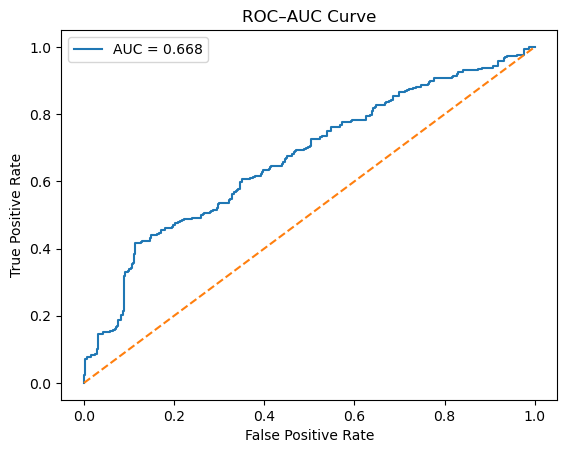

In [112]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve")
plt.legend()
plt.show()

# Threshold Tuning

Threshold tuning allows us to adjust the classification decision boundary rather than relying on the default probability threshold of 0.5.

In [113]:
thresholds = [0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresh))
    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresh))


Threshold: 0.3
Confusion Matrix:
[[446 223]
 [131 172]]
Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.67      0.72       669
        True       0.44      0.57      0.49       303

    accuracy                           0.64       972
   macro avg       0.60      0.62      0.60       972
weighted avg       0.67      0.64      0.65       972


Threshold: 0.4
Confusion Matrix:
[[571  98]
 [172 131]]
Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.85      0.81       669
        True       0.57      0.43      0.49       303

    accuracy                           0.72       972
   macro avg       0.67      0.64      0.65       972
weighted avg       0.71      0.72      0.71       972


Threshold: 0.5
Confusion Matrix:
[[593  76]
 [187 116]]
Classification Report:
              precision    recall  f1-score   support

       False       0.76      0.89      0.82       6

# Improving Model Performance with Advanced Algorithms

In [114]:
from sklearn.ensemble import RandomForestClassifier

In [115]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [116]:
y_pred_rf = rf.predict(x_test)

In [117]:
accuracy_score(y_test, y_pred_rf)

0.8508230452674898

In [118]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.89      0.89      0.89       669
        True       0.76      0.76      0.76       303

    accuracy                           0.85       972
   macro avg       0.83      0.83      0.83       972
weighted avg       0.85      0.85      0.85       972



# XGBoost

In [119]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

from sklearn.metrics import accuracy_score
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGB Accuracy: 0.9279835390946503


# LightGBM

In [120]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1
)

lgb.fit(x_train, y_train)
y_pred_lgb = lgb.predict(x_test)

print("LGB Accuracy:", accuracy_score(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 1308, number of negative: 2577
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 244
[LightGBM] [Info] Number of data points in the train set: 3885, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.336680 -> initscore=-0.678127
[LightGBM] [Info] Start training from score -0.678127
LGB Accuracy: 0.9691358024691358


# CatBoost

In [121]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, verbose=0)

cat.fit(x_train, y_train)
y_pred_cat = cat.predict(x_test)

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))

CatBoost Accuracy: 0.9300411522633745


# Model Evaluation of all Advanced Algorithms 

In [123]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

#Models

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        verbose=0
    )
}

#Evaluation
results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

#Ensemble

ensemble = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('xgb', models["XGBoost"]),
        ('lgb', models["LightGBM"])
    ],
    voting='soft'
)

ensemble.fit(x_train, y_train)
y_pred_ens = ensemble.predict(x_test)

results.append({
    "Model": "Ensemble",
    "Accuracy": accuracy_score(y_test, y_pred_ens),
    "Precision": precision_score(y_test, y_pred_ens, average='weighted'),
    "Recall": recall_score(y_test, y_pred_ens, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_ens, average='weighted')
})

#Table

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Accuracy", ascending=False)

df_results

,Model,Accuracy,Precision,Recall,F1 Score
2,LightGBM,0.969136,0.969201,0.969136,0.969163
4,Ensemble,0.941358,0.941146,0.941358,0.941223
3,CatBoost,0.930041,0.929560,0.930041,0.929576
1,XGBoost,0.927984,0.927593,0.927984,0.927716
0,Random Forest,0.850823,0.851838,0.850823,0.851283


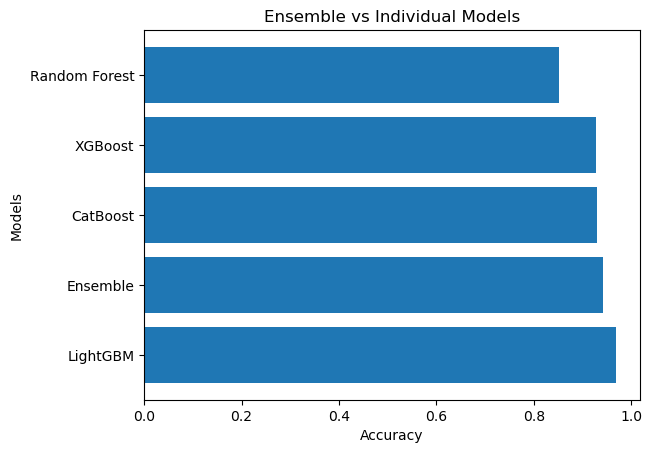

In [132]:
plt.figure()

plt.barh(df_results["Model"], df_results["Accuracy"])

plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.title("Ensemble vs Individual Models")

plt.show()

LightGBM achieves the highest accuracy, while the ensemble model performs competitively but does not significantly outperform the best individual boosting models.

# Checking Train and Test score of all Advanced Algorithms 

In [124]:
lgb.score(x_train,y_train)

0.9912483912483913

In [125]:
lgb.score(x_test,y_test)

0.9691358024691358

In [126]:
xgb.score(x_train,y_train)

0.9637065637065637

In [127]:
xgb.score(x_test,y_test)

0.9279835390946503

In [128]:
cat.score(x_test,y_test)

np.float64(0.9300411522633745)

In [129]:
cat.score(x_test,y_test)

np.float64(0.9300411522633745)

# Saving Final Trained Model (LightGBM) as .pkl

In [130]:
import pickle

pickle.dump(lgb, open("lightgbm.pkl", "wb"))